### **Remote Path**

In [ ]:
import sys

sys.path.append('/home/dyuser-e/NI_project_dyuser-e_2026/dynap-se1')

### **Local Path**

In [1]:
import sys
from pathlib import Path

dynapse_path = Path.home() / "NI_project" / "dynap-se1"
sys.path.append(str(dynapse_path))

### **Imports**

In [2]:

import samna
import numpy as np
import matplotlib.pyplot as plt
import samna.dynapse1 as dyn1

import dynapse1utils as ut
from netgen import Neuron, NetworkGenerator

import params
from params import set_params

import time
from IPython.display import Image

from tools.spikegen_tools import get_instantaneous_activity

from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import Patch

from matplotlib.ticker import MaxNLocator

### **Remote Connection**

In [ ]:
# get index for board (DONT USE TO CONNECT)

model, _ = ut.open_dynapse1(gui=False, select_device=True)

In [ ]:
model = ut.open_specific_device_in_sequence(3)

### **Local Connection**

In [3]:
model, _ = ut.open_dynapse1()

[0]:  Bus 1 Device 4 Dynapse1DevKit serial_number 00000033
0 Dynapse1Wrapper created! libcaer init...
Selected device: 00000033
Sender port: tcp://0.0.0.0:50395
Receiver port: tcp://0.0.0.0:41765
Opened device name: Dynapse1DevKit
SamnaNode ID: 1
PythonNode ID: 2
Clearing chip 0... DONE.
Clearing chip 1... DONE.
Clearing chip 2... DONE.
Clearing chip 3... DONE.


### Initialize Dynap-SE

In [64]:
api = model.get_dynapse1_api()          # get Dynapse1 api from the model
set_params(model)                       # set standard parameters


core_id = 0
config1     = model.get_configuration() 
param_group = config1.chips[0].cores[core_id].parameter_group 

### **Set Neuron/Dendrite Parameters**

In [ ]:
# AMPA fast excitatory
param_group.param_map['PS_WEIGHT_EXC_F_N'].fine_value   = 70
param_group.param_map['PS_WEIGHT_EXC_F_N'].coarse_value = 5

# NMDA slow excitatory
param_group.param_map['PS_WEIGHT_EXC_S_N'].fine_value   = 40
param_group.param_map['PS_WEIGHT_EXC_S_N'].coarse_value = 5

# GABA-B slow inhibitory
param_group.param_map['PS_WEIGHT_INH_S_N'].fine_value   = 50
param_group.param_map['PS_WEIGHT_INH_S_N'].coarse_value = 5

# GABA-A fast inhibitory
param_group.param_map['PS_WEIGHT_INH_F_N'].fine_value   = 80
param_group.param_map['PS_WEIGHT_INH_F_N'].coarse_value = 5

# NMDA slow excitatory tau: lower value = slower decay
param_group.param_map['NPDPIE_TAU_S_P'].fine_value   = 25
param_group.param_map['NPDPIE_TAU_S_P'].coarse_value = 4

# AMPA fast excitatory tau
param_group.param_map['NPDPIE_TAU_F_P'].fine_value   = 80
param_group.param_map['NPDPIE_TAU_F_P'].coarse_value = 4

# GABA-A fast inhibitory tau
param_group.param_map['NPDPII_TAU_F_P'].fine_value   = 80
param_group.param_map['NPDPII_TAU_F_P'].coarse_value = 4

# GABA-B slow inhibitory tau
param_group.param_map['NPDPII_TAU_S_P'].fine_value   = 15
param_group.param_map['NPDPII_TAU_S_P'].coarse_value = 4

# Neuron membrane voltage gain
param_group.param_map['IF_THR_N'].fine_value = 80
param_group.param_map['IF_THR_N'].coarse_value = 5

# Refactory period (Standard 4, 128?)
param_group.param_map['IF_RFR_N'].fine_value = 40
param_group.param_map['IF_RFR_N'].coarse_value = 4

# Bias Current (Standard 0, 0)
param_group.param_map["IF_DC_P"].coarse_value = 1
param_group.param_map["IF_DC_P"].fine_value = 10


### **Set Network Parameters**

In [66]:

model.update_parameter_group(param_group, 0, core_id)

NE = 255          # neurons per excitatory state population
NI = 0          # inhibitory population size
NS = 1           # number of excitatory state populations
NG = 255           # Nr of spike generators


p_S_S_AMPA      = 0.0  # Base Prob
p_S_S_NMDA      = 0.0  # NMDA/AMPA
p_S_I           = 0.0  # excitation from each state population to inhibitory pool
p_I_S_GABA_A    = 0.0  # Base Prob
p_I_S_GABA_B    = 0.0  # GABA_B/GABA_A
p_I_I           = 0.0  # optional inhibitory recurrence
p_S_S_self      = 0.0
p_I_I_self      = 0.0

p_G_S           = 1  # spike generator to state population


input_type = "uniform"
stim_rates = np.linspace(10,100,11)
stim_rates_hz = [[rate, 0, 0] for rate in stim_rates ]

dt_stim       = 3
t_steps_stim  = dt_stim*np.ones_like(stim_rates)
t_post_stim   = 2.0
t_tot         = sum(t_steps_stim) + t_post_stim

print(stim_rates)

[ 10.  19.  28.  37.  46.  55.  64.  73.  82.  91. 100.]


In [67]:

rng = np.random.default_rng(1)


net_gen = NetworkGenerator()
net_gen.clear_network()


if core_id == 2:
    gen_core_id = 0
else:
    gen_core_id = 2

spikegen_ids = [(0, gen_core_id, i + 1) for i in range(NG)]                                                          # chip, core, neuron
spikegens    = [Neuron(chip, core, nid, True) for chip, core, nid in spikegen_ids]

print(gen_core_id)



2


### Build Network

#### Connection Matrix

In [68]:
# ------------------------------------------------------------
# CONSTRUCT CONNECTION MATRIX
# ------------------------------------------------------------

N_hw  = NE * NS + NI   # all real neurons (core 0)
N_tot = N_hw + NG      # total including spike gens

C = np.zeros((N_tot, N_tot))

def get_idx(n):
    # real neurons (core 0)
    if n.core_id == core_id:
        return n.neuron_id - 1

    # spike generators (core 1)
    elif n.core_id == gen_core_id:
        return N_hw + (n.neuron_id - 1)

    else:
        raise ValueError("Unknown core_id")

def add_conn(src, tgt, syn_type):
    net_gen.add_connection(src, tgt, syn_type)

    src_idx = get_idx(src)
    tgt_idx = get_idx(tgt)

    if syn_type == dyn1.Dynapse1SynType.AMPA:
        C[src_idx, tgt_idx] = 1

    elif syn_type == dyn1.Dynapse1SynType.GABA_A:
        C[src_idx, tgt_idx] = -1

    elif syn_type == dyn1.Dynapse1SynType.NMDA:
        C[src_idx, tgt_idx] = 2

    elif syn_type == dyn1.Dynapse1SynType.GABA_B:
        C[src_idx, tgt_idx] = -2

In [69]:
def add_conn(src_neuron, tgt_neuron, syn_type):
    net_gen.add_connection(src_neuron, tgt_neuron, syn_type)

    src_neuron_idx = get_idx(src_neuron)
    tgt_neuron_idx = get_idx(tgt_neuron)

    if syn_type == dyn1.Dynapse1SynType.AMPA:
        C[src_neuron_idx, tgt_neuron_idx] = 1

    elif syn_type == dyn1.Dynapse1SynType.GABA_A:
        C[src_neuron_idx, tgt_neuron_idx] = -1

    elif syn_type == dyn1.Dynapse1SynType.NMDA:
        C[src_neuron_idx, tgt_neuron_idx] = 2

    elif syn_type == dyn1.Dynapse1SynType.GABA_B:
        C[src_neuron_idx, tgt_neuron_idx] = -2

#### Network

In [70]:

S_pops = []
E_ids  = []

next_neuron_id = 1
for s in range(NS):
    pop_ids = [(0, core_id, nid) for nid in range(next_neuron_id, next_neuron_id + NE)]
    pop     = [Neuron(chip, core, nid) for chip, core, nid in pop_ids]

    S_pops.append(pop)
    E_ids.extend(pop_ids)

    next_neuron_id += NE


I_ids = [(0, core_id, nid) for nid in range(next_neuron_id, next_neuron_id + NI)]
I_pop = [Neuron(chip, core, nid) for chip, core, nid in I_ids]


# ------------------------------------------------------------
# CONNECT SPIKEGENS -> STATE POPULATIONS - DETERMINISTIC
# ------------------------------------------------------------
for j in range(NS):
    k = 0
    for neuron in S_pops[j]:
        if k < NE * p_G_S:
            add_conn(spikegens[j], neuron, dyn1.Dynapse1SynType.AMPA)
            k += 1

# ------------------------------------------------------------
# CONNECT S_i -> S_i (Probabilistic E recurrence)
# ------------------------------------------------------------
for s in range(NS):
    for i in range(NE):
        for j in range(NE):
            if i == j and rng.random() < p_S_S_self:
                if rng.random() < p_S_S_NMDA:
                    add_conn(
                    S_pops[s][i],
                    S_pops[s][j],
                    dyn1.Dynapse1SynType.NMDA)
                else:
                    add_conn(
                    S_pops[s][i],
                    S_pops[s][j],
                    dyn1.Dynapse1SynType.AMPA
                    )
                    
            if i != j and rng.random() < p_S_S_AMPA:
                if rng.random() < p_S_S_NMDA:
                    add_conn(
                    S_pops[s][i],
                    S_pops[s][j],
                    dyn1.Dynapse1SynType.NMDA)
                else:
                    add_conn(
                    S_pops[s][i],
                    S_pops[s][j],
                    dyn1.Dynapse1SynType.AMPA
                    )

# ------------------------------------------------------------
# CONNECT S_i -> I (Probabilistic)
# ------------------------------------------------------------
for s in range(NS):
    for e_neuron in S_pops[s]:
        for i_neuron in I_pop:
            if rng.random() < p_S_I:
                add_conn(
                    e_neuron,
                    i_neuron,
                    dyn1.Dynapse1SynType.AMPA
                )

# ------------------------------------------------------------
# CONNECT I -> S_i (Probabilistic)
# ------------------------------------------------------------
for i_neuron in I_pop:
    for s in range(NS):
        for e_neuron in S_pops[s]:
            if rng.random() < p_I_S_GABA_A:
                if rng.random() < p_I_S_GABA_B:
                    add_conn(
                        i_neuron,
                        e_neuron,
                        dyn1.Dynapse1SynType.GABA_B
                    )
                else:
                    add_conn(
                        i_neuron,
                        e_neuron,
                        dyn1.Dynapse1SynType.GABA_A
                    )

# ------------------------------------------------------------
# CNNECT I -> I (Probabilistic)
# ------------------------------------------------------------
if p_I_I > 0:
    for i in range(NI):
        for j in range(NI):
            if i == j and rng.random() < p_I_I_self:
                add_conn(
                    I_pop[i],
                    I_pop[j],
                    dyn1.Dynapse1SynType.GABA_A
                )
            if i != j and rng.random() < p_I_I:
                add_conn(
                    I_pop[i],
                    I_pop[j],
                    dyn1.Dynapse1SynType.GABA_A
                )



### **Plot Connection Matrix**

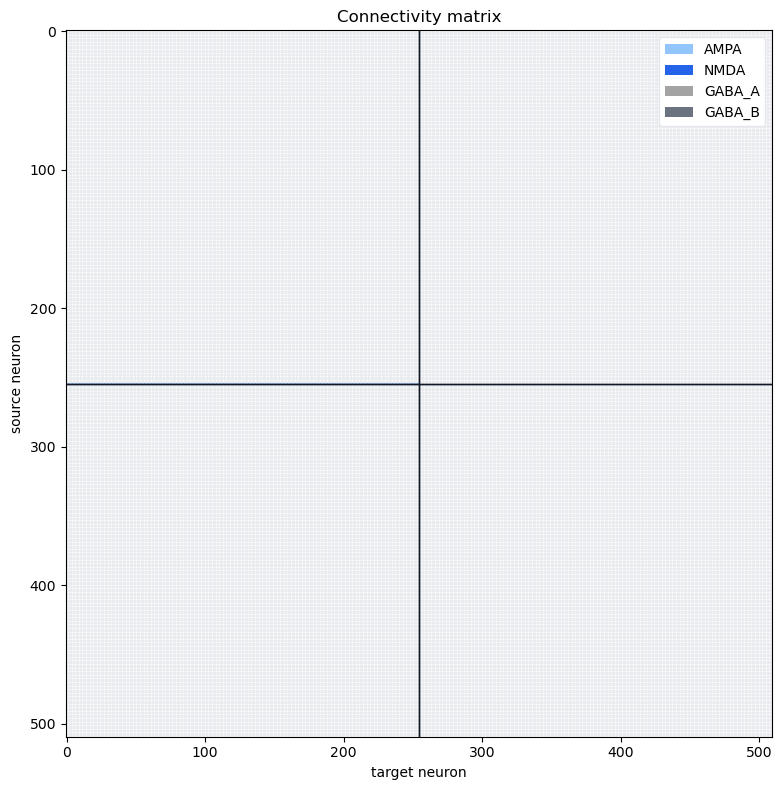

In [71]:

plt.clf()
plt.close('all')

fig, ax = plt.subplots(figsize=(8, 8))

# ------------------------------------------------------------
# DISCRETE SYNAPSE COLORS
# ------------------------------------------------------------
values = [-2, -1, 0, 1, 2]

colors = [
    "#525763",  # GABA_B  dark grey-blue
    "#acacac",  # GABA_A  light grey
    "#ffffff",  # no connection
    "#93c5fd",  # AMPA    soft blue
    "#2563eb",  # NMDA    deeper blue
]

cmap = ListedColormap(colors)

# Boundaries halfway between integer values
bounds = [-2.5, -1.5, -0.5, 0.5, 1.5, 2.5]
norm = BoundaryNorm(bounds, cmap.N)

im = ax.imshow(
    C,
    cmap=cmap,
    norm=norm,
    interpolation='none',
    aspect='equal'
)

# ------------------------------------------------------------
# GRID
# ------------------------------------------------------------
ax.set_xticks(np.arange(N_tot + 1) - 0.5, minor=True)
ax.set_yticks(np.arange(N_tot + 1) - 0.5, minor=True)

ax.grid(
    which='minor',
    color='#e5e7eb',
    linestyle='-',
    linewidth=0.4
)

ax.tick_params(which='minor', bottom=False, left=False)

# ------------------------------------------------------------
# POPULATION BOUNDARIES
# ------------------------------------------------------------
boundary_color = '#111827'

ax.axhline(NE * NS - 0.5, color=boundary_color, linewidth=1.0)
ax.axvline(NE * NS - 0.5, color=boundary_color, linewidth=1.0)

ax.axhline(N_hw - 0.5, color=boundary_color, linewidth=1.0)
ax.axvline(N_hw - 0.5, color=boundary_color, linewidth=1.0)

# ------------------------------------------------------------
# LABELS
# ------------------------------------------------------------
ax.set_xlabel("target neuron")
ax.set_ylabel("source neuron")
ax.set_title("Connectivity matrix")

# ------------------------------------------------------------
# LEGEND
# ------------------------------------------------------------
legend_elements = [
    Patch(facecolor="#93c5fd", edgecolor='none', label='AMPA'),
    Patch(facecolor="#2563eb", edgecolor='none', label='NMDA'),
    Patch(facecolor="#a3a3a3", edgecolor='none', label='GABA_A'),
    Patch(facecolor="#6b7280", edgecolor='none', label='GABA_B'),
]

ax.legend(
    handles=legend_elements,
    loc='upper right',
    frameon=True,
    framealpha=1.0,
    edgecolor='#e5e7eb'
)

plt.tight_layout()
plt.show()

In [72]:
# ------------------------------------------------------------
# APPLY CONFIGURATION
# ------------------------------------------------------------
new_config = net_gen.make_dynapse1_configuration()
model.apply_configuration(new_config)

set_params(model, param_group=param_group)

# ------------------------------------------------------------
# PREPARE POISSON INPUT
# ------------------------------------------------------------
global_poisson_gen_ids = ut.get_global_id_list(spikegen_ids)
poisson_gen            = model.get_poisson_gen()
poisson_gen.set_chip_id(0)

# set initial rates to zero
for gid in global_poisson_gen_ids:
    poisson_gen.write_poisson_rate_hz(gid, 0)

# ------------------------------------------------------------
# MONITOR NEURONS
# ------------------------------------------------------------
monitored_neurons = E_ids + I_ids
graph, filter_node, sink_node = ut.create_neuron_select_graph(model, monitored_neurons)
graph.start()
# filter_node.set_neurons(monitored_neurons)

# clear buffer
sink_node.get_events()
api.reset_timestamp()

### **Create Input Spike-Train**

In [73]:
# ------------------------------------------------------------
# CREATE POISSON SPIKE TIMES
# ------------------------------------------------------------
spike_times  = []
indices      = []
target_chips = []

t0 = 0.0

for i, duration in enumerate(t_steps_stim):

    for gen_id, rate in zip(global_poisson_gen_ids, stim_rates_hz[i]):
        
        if input_type == "poisson":
            n_spikes = np.random.poisson(rate * duration)
            times = t0 + np.sort(np.random.rand(n_spikes) * duration)
        elif input_type == "uniform":
            n_spikes = int(round(rate * duration))
            times = t0 + (np.arange(n_spikes) + 0.5) * duration / n_spikes

        spike_times.extend(times)
        indices.extend([gen_id] * n_spikes)
        target_chips.extend([0] * n_spikes)

    t0 += duration


spike_times  = np.array(spike_times)
indices      = np.array(indices)
target_chips = np.array(target_chips)

sort_idx = np.argsort(spike_times)

spike_times  = spike_times[sort_idx]
indices      = indices[sort_idx]
target_chips = target_chips[sort_idx]


fpga_spike_gen = model.get_fpga_spike_gen()

ut.set_fpga_spike_gen(
    fpga_spike_gen = fpga_spike_gen,
    spike_times    = spike_times,
    indices        = indices,
    target_chips   = target_chips,
    isi_base       = 900,
    repeat_mode    = False
)

VariableIsiMode already 1
RepeatMode already 0


In [74]:
# ------------------------------------------------------------
# CREATE EVENLY SPACED SPIKE TIMES
# ------------------------------------------------------------
spike_times  = []
indices      = []
target_chips = []

t0 = 0.0

for i, duration in enumerate(t_steps_stim):

    for gen_id, rate in zip(global_poisson_gen_ids, stim_rates_hz[i]):

        if rate <= 0:
            continue

        n_spikes = int(round(rate * duration))

        if n_spikes == 0:
            continue

        # Evenly spaced inside the interval, avoiding exact edges
        times = t0 + (np.arange(n_spikes) + 0.5) * duration / n_spikes

        spike_times.extend(times)
        indices.extend([gen_id] * n_spikes)
        target_chips.extend([0] * n_spikes)

    t0 += duration


spike_times  = np.array(spike_times)
indices      = np.array(indices)
target_chips = np.array(target_chips)

sort_idx = np.argsort(spike_times)

spike_times  = spike_times[sort_idx]
indices      = indices[sort_idx]
target_chips = target_chips[sort_idx]


fpga_spike_gen = model.get_fpga_spike_gen()

ut.set_fpga_spike_gen(
    fpga_spike_gen = fpga_spike_gen,
    spike_times    = spike_times,
    indices        = indices,
    target_chips   = target_chips,
    isi_base       = 900,
    repeat_mode    = False
)

VariableIsiMode already 1
RepeatMode already 0


In [75]:
from tools.spikegen_tools import get_instantaneous_activity

# ------------------------------------------------------------
# INSTANTANEOUS POPULATION ACTIVITY
# ------------------------------------------------------------
activity_dt_s = 0.2
exp_tc_s      = 0.02


def population_activity(t_spikes, n_neurons):
    t_spikes = np.asarray(t_spikes, dtype=float)
    t_spikes = np.sort(t_spikes[(t_spikes >= 0) & (t_spikes < t_tot)])

    if len(t_spikes) == 0:
        activity_x    = np.arange(0, t_tot, activity_dt_s)
        activity_rate = np.zeros_like(activity_x)
        return activity_rate, activity_x

    activity_hz, activity_x = get_instantaneous_activity(
        t_spikes,
        activity_dt_s,
        exp_tc_s
    )

    activity_hz = np.asarray(activity_hz, dtype=float)
    activity_x  = np.asarray(activity_x, dtype=float)

    mask = activity_x < t_tot

    activity_rate = activity_hz[mask] / n_neurons
    activity_x    = activity_x[mask]

    return activity_rate, activity_x


### **Plot Stimulation Rates**

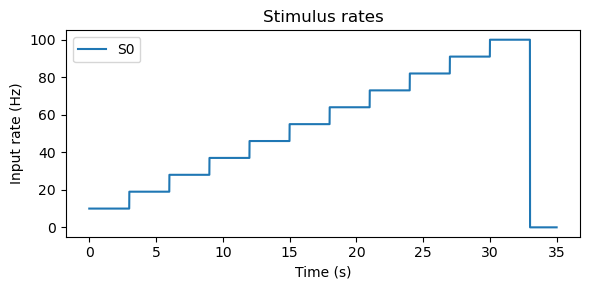

In [76]:

fs = 100

stim_rates_hz = np.array(stim_rates_hz)
t             = np.arange(0, t_tot, 1/fs)

# allocate rate matrix
rates = np.zeros((NS, len(t)))

# fill piecewise constant segments
t_cursor = 0
for i, dt in enumerate(t_steps_stim):
    idx_start = int(t_cursor * fs)
    idx_end   = int((t_cursor + dt) * fs)

    for s in range(NS):
        rates[s, idx_start:idx_end] = stim_rates_hz[i, s]

    t_cursor += dt

plt.figure(figsize=(6,3))

for s in range(NS):
    plt.plot(t, rates[s], label=f"S{s}")

plt.xlabel("Time (s)")
plt.ylabel("Input rate (Hz)")
plt.title("Stimulus rates")
plt.legend()
plt.tight_layout()
plt.show()


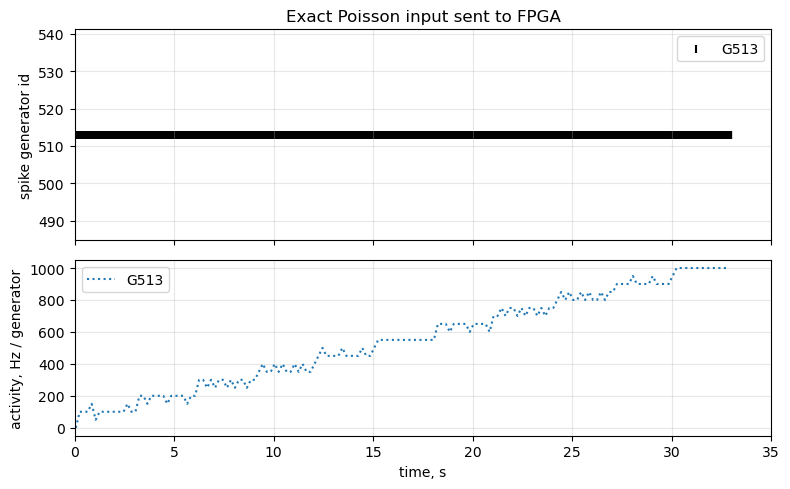

In [77]:
input_spike_t  = np.asarray(spike_times)
input_spike_id = np.asarray(indices)

color_in = 'black'

# ------------------------------------------------------------
# COMPUTE INPUT GENERATOR ACTIVITY
# ------------------------------------------------------------
G_activity_rate = []
G_activity_x    = []
G_ids           = np.unique(input_spike_id)

for gid in G_ids:
    mask = input_spike_id == gid
    rate, x = population_activity(input_spike_t[mask], n_neurons=1)

    G_activity_rate.append(rate)
    G_activity_x.append(x)

fig, (ax1, ax2) = plt.subplots(
    2, 1,
    figsize=(8, 5),
    sharex=True,
    gridspec_kw={"height_ratios": [1.2, 1]}
)

# ------------------------------------------------------------
# RASTER
# ------------------------------------------------------------
for gid in G_ids:
    mask = input_spike_id == gid

    ax1.scatter(
        input_spike_t[mask],
        input_spike_id[mask],
        marker='|',
        s=30,
        color=color_in,
        label=f'G{gid}'
    )

ax1.set_ylabel('spike generator id')
ax1.set_title('Exact Poisson input sent to FPGA')
ax1.grid(True, alpha=0.3)
ax1.legend()


# ------------------------------------------------------------
# INSTANTANEOUS ACTIVITY
# ------------------------------------------------------------
for k, gid in enumerate(G_ids):
    ax2.plot(
        G_activity_x[k],
        G_activity_rate[k],
        linestyle=':',
        label=f'G{gid}'
    )

ax2.set_xlabel('time, s')
ax2.set_ylabel('activity, Hz / generator')
ax2.set_xlim(0, t_tot)
ax2.grid(True, alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.show()

### **Run Simulation**

In [78]:
# Run Simulation
fpga_spike_gen.start()
time.sleep(t0)
fpga_spike_gen.stop()

# turn off stimulus

for gid in global_poisson_gen_ids:
    poisson_gen.write_poisson_rate_hz(gid, 0)

poisson_gen.stop()
time.sleep(t_tot)

graph.stop()
events = sink_node.get_events()

print(f"{len(events)} events recorded.")

PoissonGen already off!
2351 events recorded.


### **Post Simulation Processing**

In [79]:
# ------------------------------------------------------------
# EXTRACT EVENTS
# ------------------------------------------------------------
spike_id = []
spike_t  = []

for evt in events:
    spike_id.append(evt.neuron_id)
    spike_t.append(evt.timestamp * 1e-6)

spike_id = np.array(spike_id)
spike_t  = np.array(spike_t)


# ------------------------------------------------------------
# FILTER SPIKES BY POPULATION
# ------------------------------------------------------------
S_spike_t  = []
S_spike_id = []

for s in range(int(NS)):
    lower = s * NE
    upper = (s + 1) * NE

    mask = (spike_id > lower) & (spike_id <= upper)

    S_spike_t.append(spike_t[mask])
    S_spike_id.append(spike_id[mask])

mask_I = spike_id > NS * NE

I_spike_t  = spike_t[mask_I]
I_spike_id = spike_id[mask_I]


# ------------------------------------------------------------
# BIN FILTERED SPIKES
# ------------------------------------------------------------
fs     = 2
n_bins = int(t_tot * fs)

binPOP = np.zeros((NS + 1, n_bins))

for s in range(int(NS + 1)):

    if s < NS:
        t_spikes = S_spike_t[s]
    else:
        t_spikes = I_spike_t   # last row = inhibitory population

    t_spikes = t_spikes[t_spikes < t_tot]

    counts, _ = np.histogram(
        t_spikes,
        bins=n_bins,
        range=(0, t_tot)
    )

    binPOP[s, :] = counts

# total excitatory activity (all S populations pooled)
binPOP_E = np.sum(binPOP[:NS, :], axis=0)

# Mean excitatory activity (all S populations pooled)
binPOP_tot_mean = np.sum(binPOP) / (NS * NE)


# ------------------------------------------------------------
# POPULATION FIRING ACTIVITY
# ------------------------------------------------------------
idx_end = int(t_tot * fs)
t_axis  = np.arange(idx_end) / fs

binPOP_rate = binPOP[:, :idx_end] * fs / NE

# ---------------------------------------------------------
# FIRING ACTIVITY PER STIMULUS WINDOW
# ------------------------------------------------------------

#TODO Make independent of binPOP

stim_start = np.cumsum(np.r_[0, t_steps_stim[:-1]])
stim_end   = stim_start + t_steps_stim

out_rates = np.zeros((NS, len(stim_rates)))

for s in range(int(NS)):
    for i, (t0, t1) in enumerate(zip(stim_start, stim_end)):
        b0 = int(t0 * fs)
        b1 = int(t1 * fs)

        n_spikes = np.sum(binPOP[s, b0:b1])

        out_rates[s, i] = n_spikes / (t1 - t0)





S0
------------------------------
average count       = 9.22
standard deviation  = 51.20
deviating neurons including missing ones:
  neuron   1: count =    0   (missing / zero count)
  neuron   2: count =    0   (missing / zero count)
  neuron   4: count =    0   (missing / zero count)
  neuron   9: count =    0   (missing / zero count)
  neuron  10: count =    0   (missing / zero count)
  neuron  12: count =    0   (missing / zero count)
  neuron  13: count =    0   (missing / zero count)
  neuron  14: count =    0   (missing / zero count)
  neuron  18: count =    0   (missing / zero count)
  neuron  19: count =    0   (missing / zero count)
  neuron  20: count =    0   (missing / zero count)
  neuron  21: count =    0   (missing / zero count)
  neuron  22: count =    0   (missing / zero count)
  neuron  23: count =    0   (missing / zero count)
  neuron  25: count =    0   (missing / zero count)
  neuron  26: count =    0   (missing / zero count)
  neuron  27: count =    0   (missin

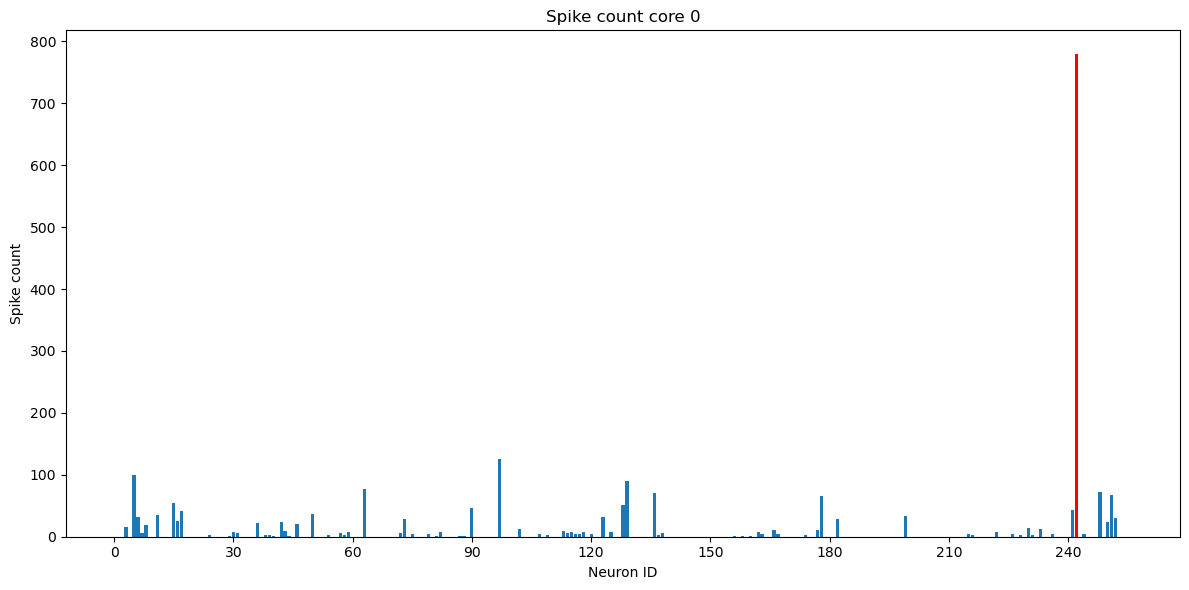


Summary of all deviating neurons
S0, neuron   1: count =    0   (missing / zero count)
S0, neuron   2: count =    0   (missing / zero count)
S0, neuron   4: count =    0   (missing / zero count)
S0, neuron   9: count =    0   (missing / zero count)
S0, neuron  10: count =    0   (missing / zero count)
S0, neuron  12: count =    0   (missing / zero count)
S0, neuron  13: count =    0   (missing / zero count)
S0, neuron  14: count =    0   (missing / zero count)
S0, neuron  18: count =    0   (missing / zero count)
S0, neuron  19: count =    0   (missing / zero count)
S0, neuron  20: count =    0   (missing / zero count)
S0, neuron  21: count =    0   (missing / zero count)
S0, neuron  22: count =    0   (missing / zero count)
S0, neuron  23: count =    0   (missing / zero count)
S0, neuron  25: count =    0   (missing / zero count)
S0, neuron  26: count =    0   (missing / zero count)
S0, neuron  27: count =    0   (missing / zero count)
S0, neuron  28: count =    0   (missing / zero c

In [80]:

x_std = 2.5  # threshold: deviations larger than x_std * std

all_deviating_neurons = []

for s in range(NS):

    expected_ids = np.array([neuron.neuron_id for neuron in S_pops[s]])

    ids, counts = np.unique(S_spike_id[s], return_counts=True)

    count_dict = dict(zip(ids, counts))

    full_counts = np.array([
        count_dict.get(neuron_id, 0) for neuron_id in expected_ids
    ])

    missing_mask = full_counts == 0
    missing_ids  = expected_ids[missing_mask]

    mean_count = np.mean(full_counts)
    std_count  = np.std(full_counts)

    if std_count > 0:
        outlier_mask = np.abs(full_counts - mean_count) > x_std * std_count
    else:
        outlier_mask = np.zeros_like(full_counts, dtype=bool)

    combined_mask = outlier_mask | missing_mask

    deviating_ids    = expected_ids[combined_mask]
    deviating_counts = full_counts[combined_mask]

    print(f"\nS{s}")
    print("-" * 30)
    print(f"average count       = {mean_count:.2f}")
    print(f"standard deviation  = {std_count:.2f}")

    if len(deviating_ids) > 0:
        print("deviating neurons including missing ones:")

        for neuron_id, count in zip(deviating_ids, deviating_counts):

            reasons = []

            if count == 0:
                reasons.append("missing / zero count")

            if neuron_id in expected_ids[outlier_mask]:
                reasons.append(f"> {x_std} std from mean")

            reason_str = ", ".join(reasons)

            print(f"  neuron {neuron_id:3d}: count = {count:4d}   ({reason_str})")

            all_deviating_neurons.append((s, neuron_id, count, reason_str))
    else:
        print("no deviating or missing neurons")

    colors = ["red" if is_deviating else "C0" for is_deviating in combined_mask]

    fig, ax = plt.subplots(figsize=(12, 6))

    ax.bar(expected_ids, full_counts, width=0.8, color=colors)

    ax.set_xlabel("Neuron ID")
    ax.set_ylabel("Spike count")
    ax.set_title(f"Spike count core {core_id}")

    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    ax.yaxis.set_major_locator(MaxNLocator(integer=True))

    plt.tight_layout()
    plt.show()


print("\nSummary of all deviating neurons")
print("=" * 40)

if len(all_deviating_neurons) > 0:
    for s, neuron_id, count, reason in all_deviating_neurons:
        print(f"S{s}, neuron {neuron_id:3d}: count = {count:4d}   ({reason})")
else:
    print("No deviating or missing neurons found.")

In [81]:
print(counts)

[ 16 100  32   6  19  35  55  26  41   2   1   7   6  22   2   3   1  24
   9   1  21  36   3   6   2   7  77   6  29   5   5   1   7   1   1  46
 125  13   5   3   9   6   7   5   4   7   4  32   8  51  90  70   3   6
   1   1   1   7   4  11   4   2  11  65  28  33   4   2   8   4   3  14
   3  12   5  43 779   4  72  23  68  30]


In [82]:
S_activity_rate = []
S_activity_x    = []

for s in range(int(NS)):
    rate, x = population_activity(S_spike_t[s], NE)

    S_activity_rate.append(rate)
    S_activity_x.append(x)


I_activity_rate, I_activity_x = population_activity(I_spike_t, NI)


# total excitatory activity, all S populations pooled
E_spike_t = np.concatenate(S_spike_t)

E_activity_rate, E_activity_x = population_activity(
    E_spike_t,
    int(NS) * NE
)

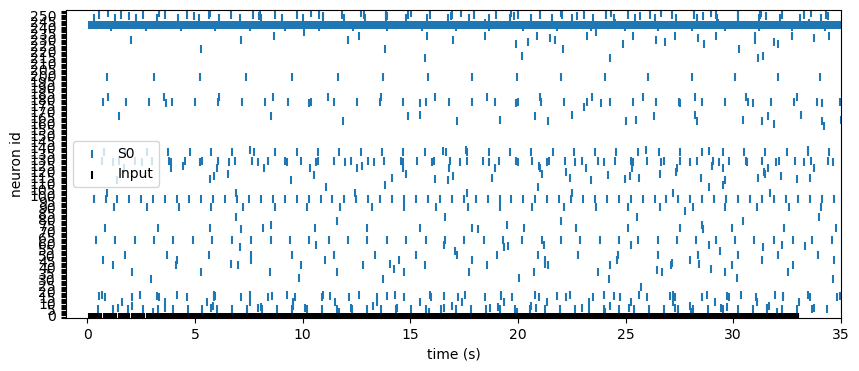

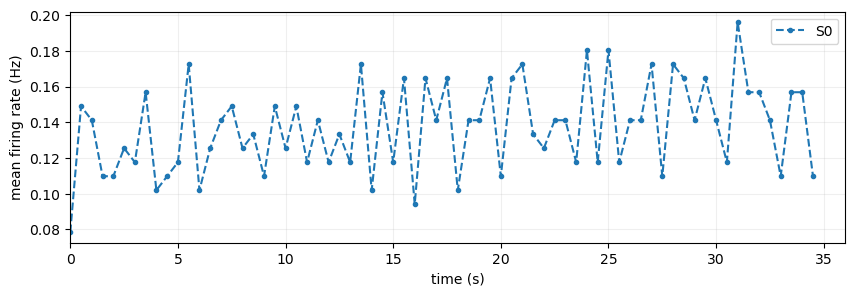

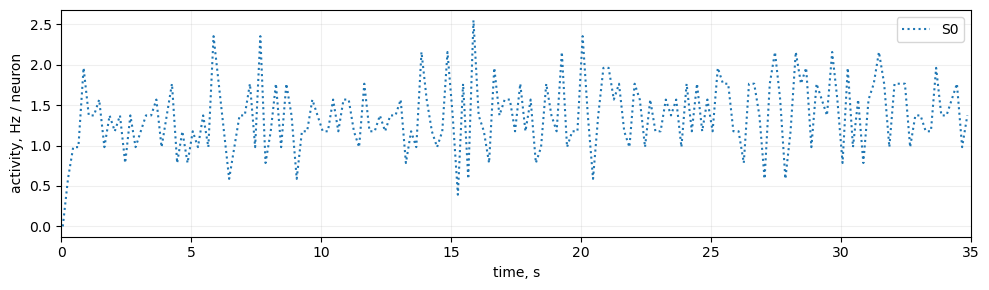

In [83]:
color_I  = 'tab:red'
color_S  = ['tab:blue', 'tab:orange', 'tab:green', color_I]  # one per S population

# ------------------------------------------------------------
# PLOT SPIKE RASTER
# ------------------------------------------------------------
fig1, ax1 = plt.subplots(figsize=(10, 4))

for s in range(int(NS)):
    ax1.scatter(
        S_spike_t[s],
        S_spike_id[s],
        marker='|',
        color=color_S[s],
        label=f'S{s}'
    )

if I_spike_t.size > 0:
     ax1.scatter(
        I_spike_t,
        I_spike_id,
        marker='|',
        color= color_I,
        label='I'
    )

ax1.scatter(
    input_spike_t,
    -1 * np.ones_like(input_spike_t),
    marker='|',
    color= color_in,
    label='Input'
)

ticks = np.arange(-NG, NS*NE + NI, 1)
#ticks = np.arange(0, NE, 1)
ax1.set_yticks(ticks)

# show labels only every k neurons
k = 5
labels = [str(t) if t % k == 0 else '' for t in ticks]
ax1.set_yticklabels(labels)

ax1.set_xlabel('time (s)')
ax1.set_ylabel('neuron id')
ax1.set_ylim(-2, N_hw)
ax1.set_xlim(-1, t_tot)
ax1.legend()


# ------------------------------------------------------------
# PLOT FIRING ACTIVITY AGAINST TIME
# ------------------------------------------------------------
fig2, ax2 = plt.subplots(figsize=(10, 3))

for s in range(int(NS)):
    ax2.plot(
        t_axis,
        binPOP_rate[s],
        marker      = 'o',
        linestyle   = '--',
        color       = color_S[s],
        markersize  = 3,
        label       = f'S{s}'
    )

if I_spike_t.size > 0:
     ax2.plot(
            t_axis,
            binPOP_rate[NS],
            marker     = 'o',
            linestyle  = '--',
            color      = color_I,
            markersize = 3,
            label      = f'I'
        )

ax2.set_xlabel('time (s)')
ax2.set_ylabel('mean firing rate (Hz)')
ax2.grid(True, alpha=0.2)
ax2.set_xlim(0, t_tot+1)
ax2.legend()


# ------------------------------------------------------------
# PLOT FIRING ACTIVITY AGAINST INPUT STIMULUS
# ------------------------------------------------------------
fig3, ax3 = plt.subplots(figsize=(10, 3))

for s in range(int(NS)):
    ax3.plot(
        S_activity_x[s],
        S_activity_rate[s],
        linestyle  = ':',
        color       = color_S[s],
        label=f"S{s}"
    )

if I_spike_t.size > 0:
    ax3.plot(
        I_activity_x,
        I_activity_rate,
        linestyle  = ':',
        color = color_I,
        label="I"
    )

ax3.set_xlabel("time, s")
ax3.set_ylabel("activity, Hz / neuron")
ax3.set_xlim(0, t_tot)
ax3.legend()
ax3.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

